In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,auc,roc_curve

In [78]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [74]:
data = pd.read_csv(r"C:\Users\NIT\Downloads\Churn_Modelling.csv")



0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

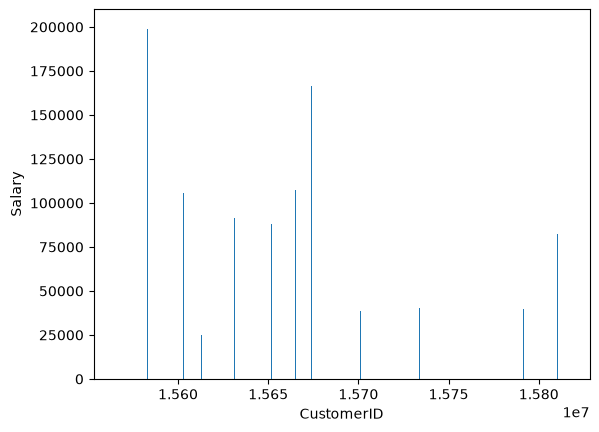

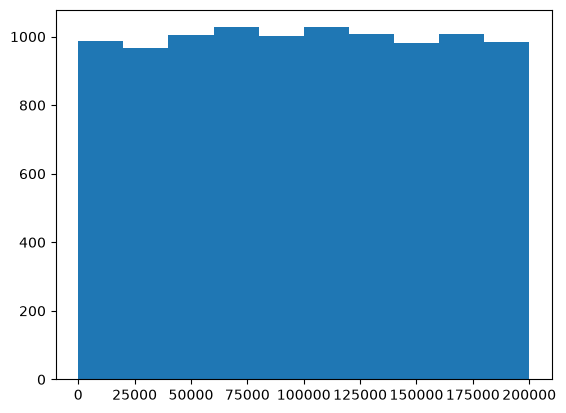

In [122]:
import matplotlib.pyplot as plt
plt.bar(data["CustomerId"],data["EstimatedSalary"])
plt.xlabel("CustomerID")
plt.ylabel("Salary")
plt.show()
plt.hist(data["EstimatedSalary"])
plt.show()

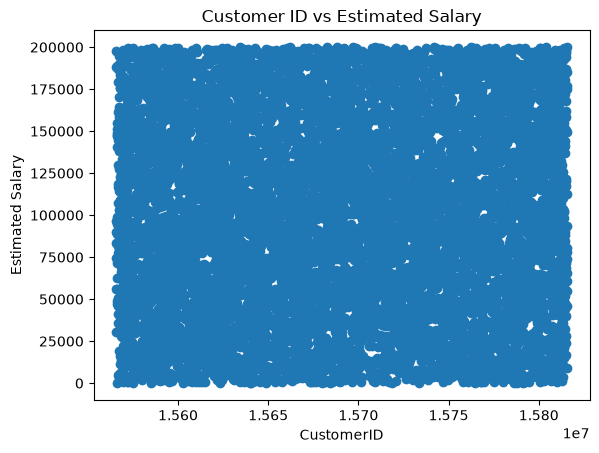

In [123]:
plt.scatter(data["CustomerId"], data["EstimatedSalary"])

plt.xlabel("CustomerID")
plt.ylabel("Estimated Salary")
plt.title("Customer ID vs Estimated Salary")

plt.show()

In [84]:
from sklearn.compose import ColumnTransformer
x=data.drop(columns=["RowNumber","Surname","Exited",'CustomerId'],errors="ignore")
y= data["Exited"]
x= pd.get_dummies(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [107]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Exited
0    6356
1    1644
Name: count, dtype: int64

After SMOTE:
Exited
0    6356
1    6356
Name: count, dtype: int64


In [73]:
print(y_train.value_counts())
print(y_test.value_counts())

Exited
0    6356
1    1644
Name: count, dtype: int64
Exited
0    1607
1     393
Name: count, dtype: int64


C:\Users\NIT\miniforge3\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[LibSVM]0.8035


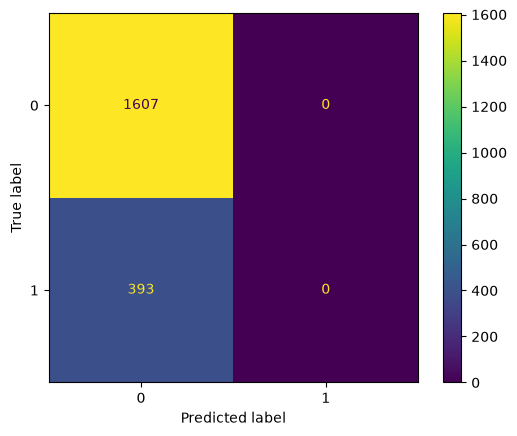

In [109]:
model_svm = SVC(kernel = "rbf",degree=3,gamma='scale',verbose=True,shrinking=False,
    probability=True,max_iter=10000,
    random_state=42, class_weight = None
)
model_svm.fit(x_train,y_train)

y_pred = model_svm.predict(x_test)

print(accuracy_score(y_test,y_pred))
confusion_matrix_svm = confusion_matrix(y_test,y_pred)
disp_svc = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_svm, display_labels = [0,1])
disp_svc.plot()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear","sigmoid"]
}

grid_rf = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print("Best parameters:")
print(grid_rf.best_params_)

print("\nBest CV accuracy:")
print(grid_rf.best_score_)


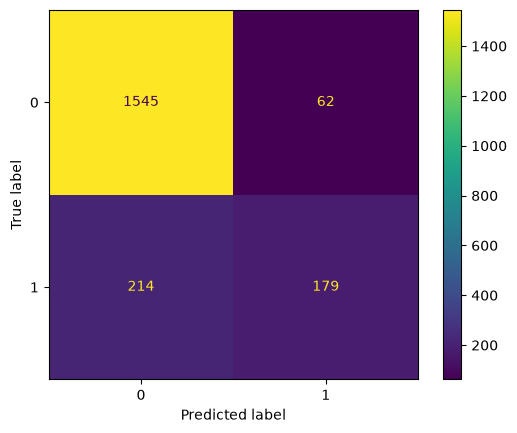

In [99]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=1000, random_state=42,max_depth=200,min_samples_split=10,
                                   max_features="sqrt",min_samples_leaf = 1,)
model_rf.fit(x_train,y_train)
y_pred = model_rf.predict(x_test)
accuracy_score(y_test,y_pred)
confusion_matrix_rf = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_rf,display_labels= [0,1])
disp.plot()
plt.show()


In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(x_train, y_train)

print("Best parameters:")
print(grid_rf.best_params_)

print("\nBest CV accuracy:")
print(grid_rf.best_score_)


Fitting 10 folds for each of 576 candidates, totalling 5760 fits
Best parameters:
{'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Best CV accuracy:
0.864625


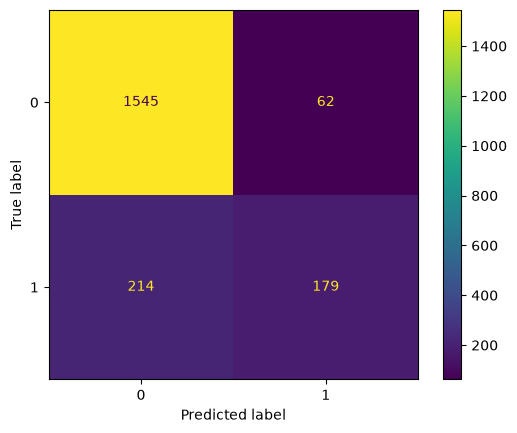

In [118]:
from sklearn.tree import DecisionTreeClassifier

model_decision = DecisionTreeClassifier(criterion='gini',splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                              max_features=None, random_state=None, max_leaf_nodes=None, 
                              min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

model_decision.fit(x_train,y_train)
y_pred = model_decision.predict(x_test)
accuracy_score(y_test,y_pred)
confusion_matrix_dt = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_dt,display_labels= [0,1])
disp.plot()
plt.show()

C:\Users\NIT\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy : 0.7905
Testing Accuracy : 0.8
[[1567   40]
 [ 360   33]]


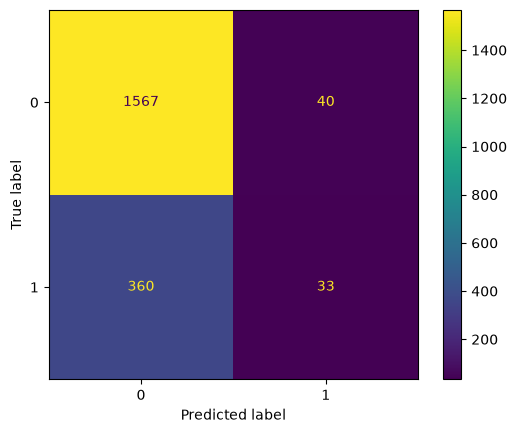

In [120]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(x_train, y_train)

y_pred = model_lr.predict(x_test)

print("Training Accuracy :", model_lr.score(x_train, y_train))
print("Testing Accuracy :", model_lr.score(x_test, y_test))

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp_lr = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0,1])
disp_lr.plot()
plt.show()